# UrWay Title → Category Predictor

This notebook builds a strong text-classification pipeline that predicts a video's category from its title.

It is organized into clear sections:
- quick data sampling
- category and keyword exploration
- label encoding
- visualizations
- model training and validation
- overfitting / underfitting control
- final evaluation and extra plots

In [38]:
from pathlib import Path
import copy
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_PATH = Path("UrWay Final Dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH.resolve()}")

raw_df = pd.read_csv(
    DATA_PATH,
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8",
)

print(f"Loaded rows: {len(raw_df):,}")
print(f"Loaded columns: {list(raw_df.columns)}")
raw_df.head()

Loaded rows: 20,572
Loaded columns: ['title', 'Category']


,title,Category
0,Nepse Technical Analysis for Beginners | Nepal Share Market | Full Course by CA Supriya Sharma,Stock Market Trading and Investment Analysis
1,Who are The Original Muslims??😱 #shivamsingh #ytshorts #shorts #muslim #indianculture,"Entertainment: Music, Movies, Comedy, Trailers, and Pop Culture"
2,State Management in React – Redux Redux Toolkit State Management,MERN Stack Web Development Tutorial
3,Intraday me profit hone ke turant EXIT ho #shorts,Stock Market Trading and Investment Analysis
4,Back Propagation Algorithm /Back Propagation Of Error (Part-1)Explained With Solved Example in Hindi Backpropagation...,Machine Learning and Deep Learning Course


In [39]:
# Keep only the needed columns, remove blanks/duplicates, and create a reusable clean-title column.
df = raw_df.copy()
df = df[["title", "Category"]].dropna().copy()
df["title"] = df["title"].astype(str).str.strip()
df["Category"] = df["Category"].astype(str).str.strip()
df = df[(df["title"] != "") & (df["Category"] != "")].drop_duplicates().reset_index(drop=True)


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_title"] = df["title"].map(clean_text)

print(f"Rows after cleaning: {len(df):,}")
print(f"Unique categories: {df['Category'].nunique():,}")
print(f"Missing values after cleaning:\n{df.isna().sum()}")

print("\n10 random sample rows:")
display(df.sample(10, random_state=RANDOM_STATE)[["title", "Category"]])

Rows after cleaning: 18,106
Unique categories: 24
Missing values after cleaning:
title          0
Category       0
clean_title    0
dtype: int64

10 random sample rows:


,title,Category
2458,How to deliver a killer presentation,Leadership and Communication Skills Training
2495,The Fallout - Official Trailer Starring Jenna Ortega &amp; Maddie Ziegler,"Entertainment: Music, Movies, Comedy, Trailers, and Pop Culture"
7444,AWS or azure cloud platform in Telugu @LuckyTechzone,Cloud Computing AWS Azure
3769,#aitools for #digitalmarketing #marketing #ai,Digital Marketing and SEO Strategy for Beginners
563,"Build Spotify With Flutter - Bloc , Clean Architecture , Firebase , Figma Flutter Clean Architecture",Flutter and Firebase App Development
14393,Inventory Management System in Flutter |Firestore #firebase #fluttertutorial #coding #flutter,Flutter and Firebase App Development
9601,Cyber Security Full Course Free 2026 | Cyber Security Course For Beginners | Intellipaat,Ethical Hacking and Network Security Full Course
2448,React and the Virtual DOM React Virtual DOM,MERN Stack Web Development Tutorial
13316,How I become a Chartered Accountant,Chartered Accountancy and Financial Auditing
8398,"Corporate Laws and Governance II M.com II PG Examination , Dec. 2024 II under NEP Company Law and Governance",Commerce


## 1) Category overview and keyword discovery

This section identifies the dominant category types and the most informative words or phrases appearing in the video titles.

Total category types: 24
Top 10 categories:



,count
Category,
Cloud Computing AWS Azure,1523
Machine Learning and Deep Learning Course,1520
Blockchain and Solidity Programming,1507
MERN Stack Web Development Tutorial,1468
Data Science and Data Analytics,1432
Flutter and Firebase App Development,1407
Medical,943
Commerce,931
"Entertainment: Music, Movies, Comedy, Trailers, and Pop Culture",583


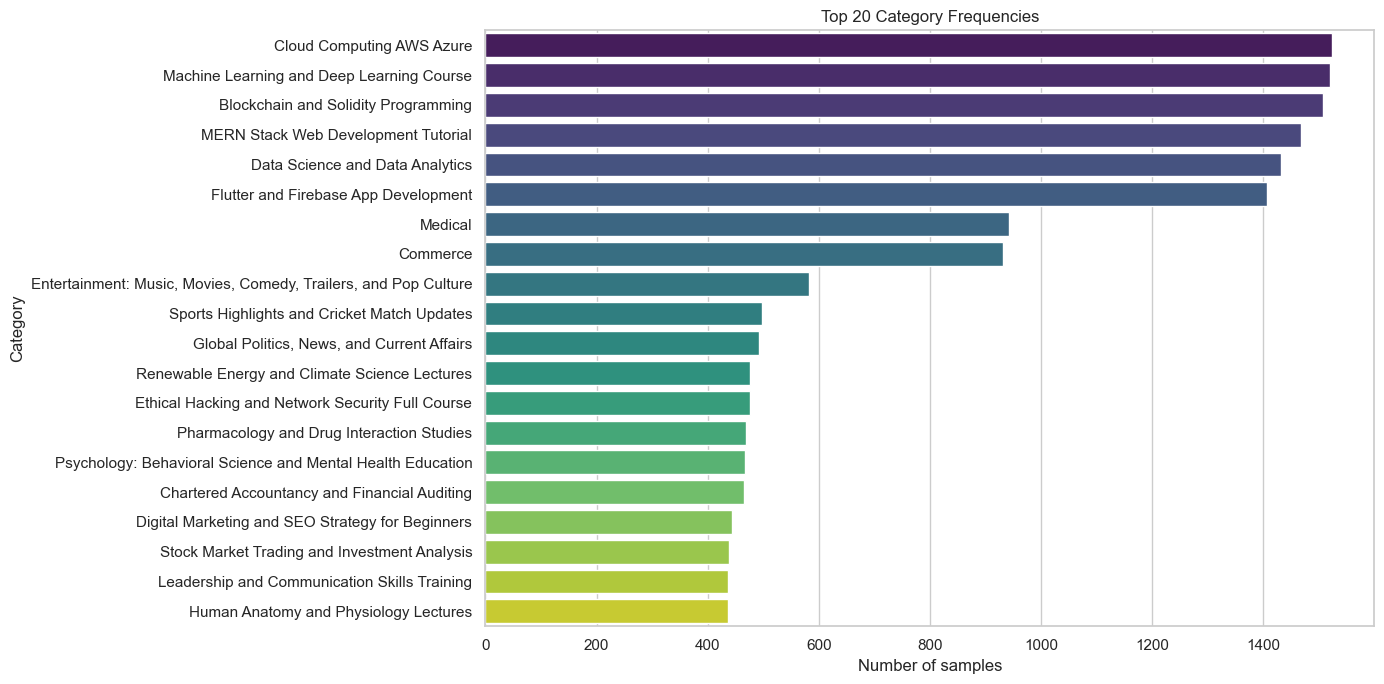

In [40]:
# Category counts and a quick plot of the most frequent categories.
category_counts = df["Category"].value_counts()
print("Total category types:", category_counts.shape[0])
print("Top 10 categories:\n")
display(category_counts.head(10).to_frame(name="count"))

plt.figure(figsize=(14, 7))
sns.barplot(
    x=category_counts.head(20).values,
    y=category_counts.head(20).index,
    palette="viridis",
)
plt.title("Top 20 Category Frequencies")
plt.xlabel("Number of samples")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

,keyword,count
0,data,2077
1,amp,2067
2,flutter,1683
3,vs,1683
4,shorts,1346
5,learning,1101
6,management,1092
7,explained,1072
8,tutorial,1042
9,course,1007


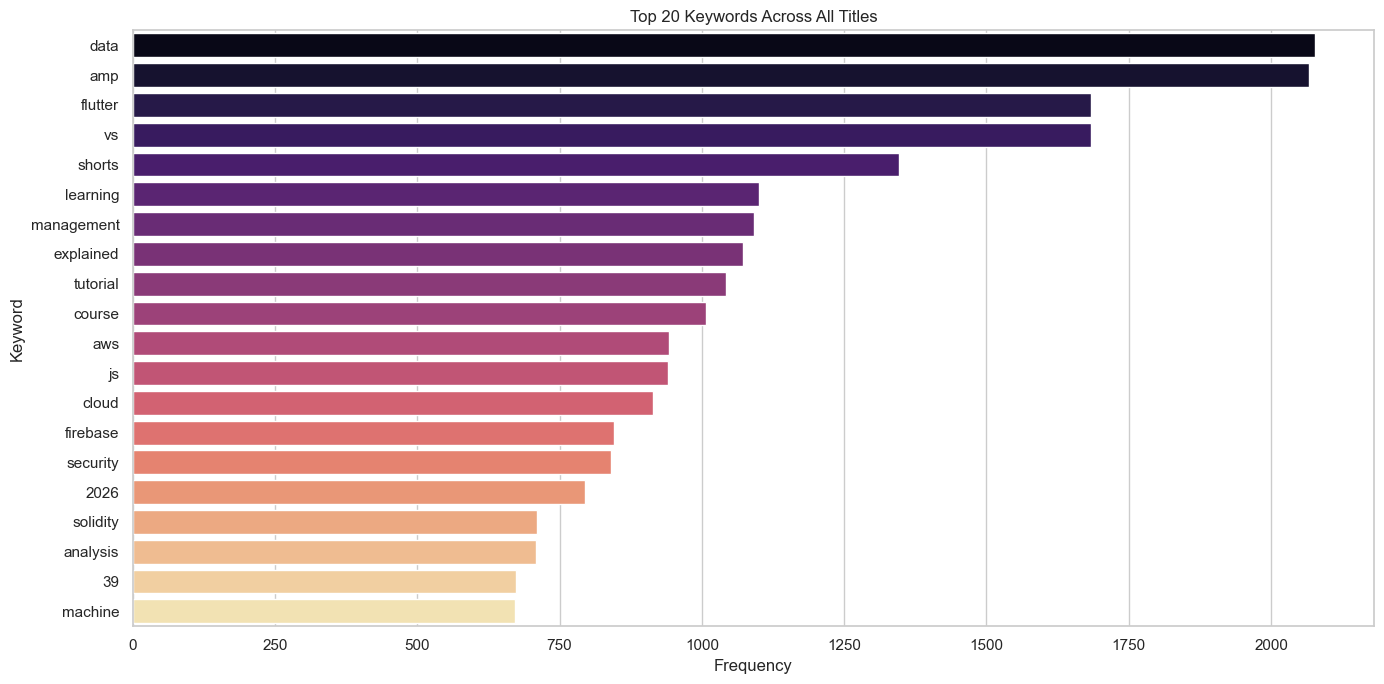

Keyword signatures for the largest categories:


,Category,Top keywords
0,Cloud Computing AWS Azure,"aws, cloud, azure, docker, vs, security, kubernetes, terraform"
1,Machine Learning and Deep Learning Course,"learning, machine, machine learning, networks, neural, ai, deep, deep learning"
2,Blockchain and Solidity Programming,"solidity, blockchain, smart, js, ethereum, contract, smart contract, web3"
3,MERN Stack Web Development Tutorial,"stack, react, js, mern, mern stack, node, mongodb, vs"
4,Data Science and Data Analytics,"data, analysis, sql, data analysis, python, seaborn, time, series"
5,Flutter and Firebase App Development,"flutter, firebase, app, bloc, tutorial, amp, state, architecture"
6,Medical,"pathology, ecg, brain, anatomy, immunology, microbiology, pharmacology, interpretation"
7,Commerce,"management, financial, accounting, policy, portfolio, cost, fiscal, gst"
8,"Entertainment: Music, Movies, Comedy, Trailers, and Pop Culture","comedy, shorts, movie, 39, funny, amp, trailer, quot"
9,Sports Highlights and Cricket Match Updates,"match, vs, cricket, highlights, 2026, ipl, live, cup"


In [41]:
# Extract the most informative overall keywords and a keyword signature for the largest categories.
keyword_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=8000,
)
keyword_matrix = keyword_vectorizer.fit_transform(df["clean_title"])
keyword_names = np.array(keyword_vectorizer.get_feature_names_out())

overall_keyword_counts = np.asarray(keyword_matrix.sum(axis=0)).ravel()
top_keyword_idx = overall_keyword_counts.argsort()[::-1][:20]
top_keywords = pd.DataFrame(
    {"keyword": keyword_names[top_keyword_idx], "count": overall_keyword_counts[top_keyword_idx]}
)

display(top_keywords)

plt.figure(figsize=(14, 7))
sns.barplot(data=top_keywords, x="count", y="keyword", palette="magma")
plt.title("Top 20 Keywords Across All Titles")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()


def category_keyword_signature(frame: pd.DataFrame, top_n: int = 8, keywords_per_category: int = 6) -> pd.DataFrame:
    rows = []
    for category in frame["Category"].value_counts().head(top_n).index:
        subset = frame.loc[frame["Category"] == category, "clean_title"]
        mat = keyword_vectorizer.transform(subset)
        counts = np.asarray(mat.sum(axis=0)).ravel()
        indices = counts.argsort()[::-1][:keywords_per_category]
        rows.append(
            {
                "Category": category,
                "Top keywords": ", ".join(keyword_names[indices]),
            }
        )
    return pd.DataFrame(rows)

print("Keyword signatures for the largest categories:")
display(category_keyword_signature(df, top_n=10, keywords_per_category=8))

In [42]:
# Label encode the target category into a numeric category_id.
label_encoder = LabelEncoder()
df["category_id"] = label_encoder.fit_transform(df["Category"])

category_map = pd.DataFrame(
    {
        "category_id": np.arange(len(label_encoder.classes_)),
        "Category": label_encoder.classes_,
    }
)

display(category_map.head(15))
print(f"Number of encoded classes: {len(label_encoder.classes_):,}")
print("\nExample encoded rows:")
display(df[["title", "Category", "category_id"]].head(10))

,category_id,Category
0,0,Blockchain and Solidity Programming
1,1,Business Law and Corporate Governance
2,2,Chartered Accountancy and Financial Auditing
3,3,Cloud Computing AWS Azure
4,4,Commerce
5,5,Data Science and Data Analytics
6,6,Data Structures and Algorithms for Placements
7,7,Digital Marketing and SEO Strategy for Beginners
8,8,"Entertainment: Music, Movies, Comedy, Trailers, and Pop Culture"
9,9,Ethical Hacking and Network Security Full Course


Number of encoded classes: 24

Example encoded rows:


,title,Category,category_id
0,Nepse Technical Analysis for Beginners | Nepal Share Market | Full Course by CA Supriya Sharma,Stock Market Trading and Investment Analysis,22
1,Who are The Original Muslims??😱 #shivamsingh #ytshorts #shorts #muslim #indianculture,"Entertainment: Music, Movies, Comedy, Trailers, and Pop Culture",8
2,State Management in React – Redux Redux Toolkit State Management,MERN Stack Web Development Tutorial,14
3,Intraday me profit hone ke turant EXIT ho #shorts,Stock Market Trading and Investment Analysis,22
4,Back Propagation Algorithm /Back Propagation Of Error (Part-1)Explained With Solved Example in Hindi Backpropagation...,Machine Learning and Deep Learning Course,15
5,Cyber Security Full Course 2026 | Cyber Security In 24 Hours | Cybersecurity Tutorial | Simplilearn,Ethical Hacking and Network Security Full Course,9
6,Spark Tutorial For Beginners | Big Data Spark Tutorial | Apache Spark Tutorial | Simplilearn Big Data Processing wit...,Data Science and Data Analytics,5
7,Booklist for history for UPSC CSE | Divya tanwar rank (438)| #heavenlbsnaa,UPSC Civil Services Full Lectures and Preparation,23
8,"Hypothesis testing: step-by-step, p-value, t-test for difference of two means - Statistics Help Statistical Hypothes...",Data Science and Data Analytics,5
9,#17 Tables in HTML | Full Stack Web Development | Mern Stack | Watch Now!✔️🔥,MERN Stack Web Development Tutorial,14


## 2) Train / validation / test split and TF-IDF features

We keep the split stratified so every set preserves the category distribution as much as possible.

In [43]:
# Create a stratified 70/15/15 split.
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["category_id"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["category_id"],
)

print(f"Train size: {len(train_df):,}")
print(f"Validation size: {len(val_df):,}")
print(f"Test size: {len(test_df):,}")

# TF-IDF features for the classical models.
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=50000,
)

X_train = tfidf_vectorizer.fit_transform(train_df["clean_title"])
X_val = tfidf_vectorizer.transform(val_df["clean_title"])
X_test = tfidf_vectorizer.transform(test_df["clean_title"])

y_train = train_df["category_id"].to_numpy()
y_val = val_df["category_id"].to_numpy()
y_test = test_df["category_id"].to_numpy()

print("TF-IDF feature matrix shape:", X_train.shape)

Train size: 12,674
Validation size: 2,716
Test size: 2,716
TF-IDF feature matrix shape: (12674, 18714)


## 3) Model benchmarking

We compare a few strong, lightweight baselines and keep the one with the best validation performance.

In [44]:
# Compare a few solid classical models on the validation set.
models = {
    "MultinomialNB": MultinomialNB(alpha=0.3),
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        solver="saga",
        n_jobs=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "LinearSVC": LinearSVC(C=1.5, class_weight="balanced", random_state=RANDOM_STATE),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    val_pred = model.predict(X_val)
    results.append(
        {
            "model": name,
            "validation_accuracy": accuracy_score(y_val, val_pred),
            "validation_f1_macro": f1_score(y_val, val_pred, average="macro"),
        }
    )

results_df = pd.DataFrame(results).sort_values(
    ["validation_f1_macro", "validation_accuracy"], ascending=False
)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Best validation model: {best_model_name}")

,model,validation_accuracy,validation_f1_macro
2,LinearSVC,0.943299,0.922225
1,LogisticRegression,0.935567,0.915476
0,MultinomialNB,0.900589,0.876178


Best validation model: LinearSVC


## 4) Final evaluation on the test set

After choosing the best validation model, we retrain it on train + validation data and evaluate only once on the holdout test set.

Test accuracy: 0.9599
Test macro F1:  0.9450

Classification report:

                                                                 precision    recall  f1-score   support

                            Blockchain and Solidity Programming       1.00      1.00      1.00       226
                          Business Law and Corporate Governance       0.98      0.95      0.97        64
                   Chartered Accountancy and Financial Auditing       0.97      0.97      0.97        70
                                      Cloud Computing AWS Azure       0.99      0.96      0.98       228
                                                       Commerce       0.99      1.00      0.99       139
                                Data Science and Data Analytics       0.98      0.98      0.98       215
                  Data Structures and Algorithms for Placements       0.90      0.98      0.94        62
               Digital Marketing and SEO Strategy for Beginners       0.94      0.95     

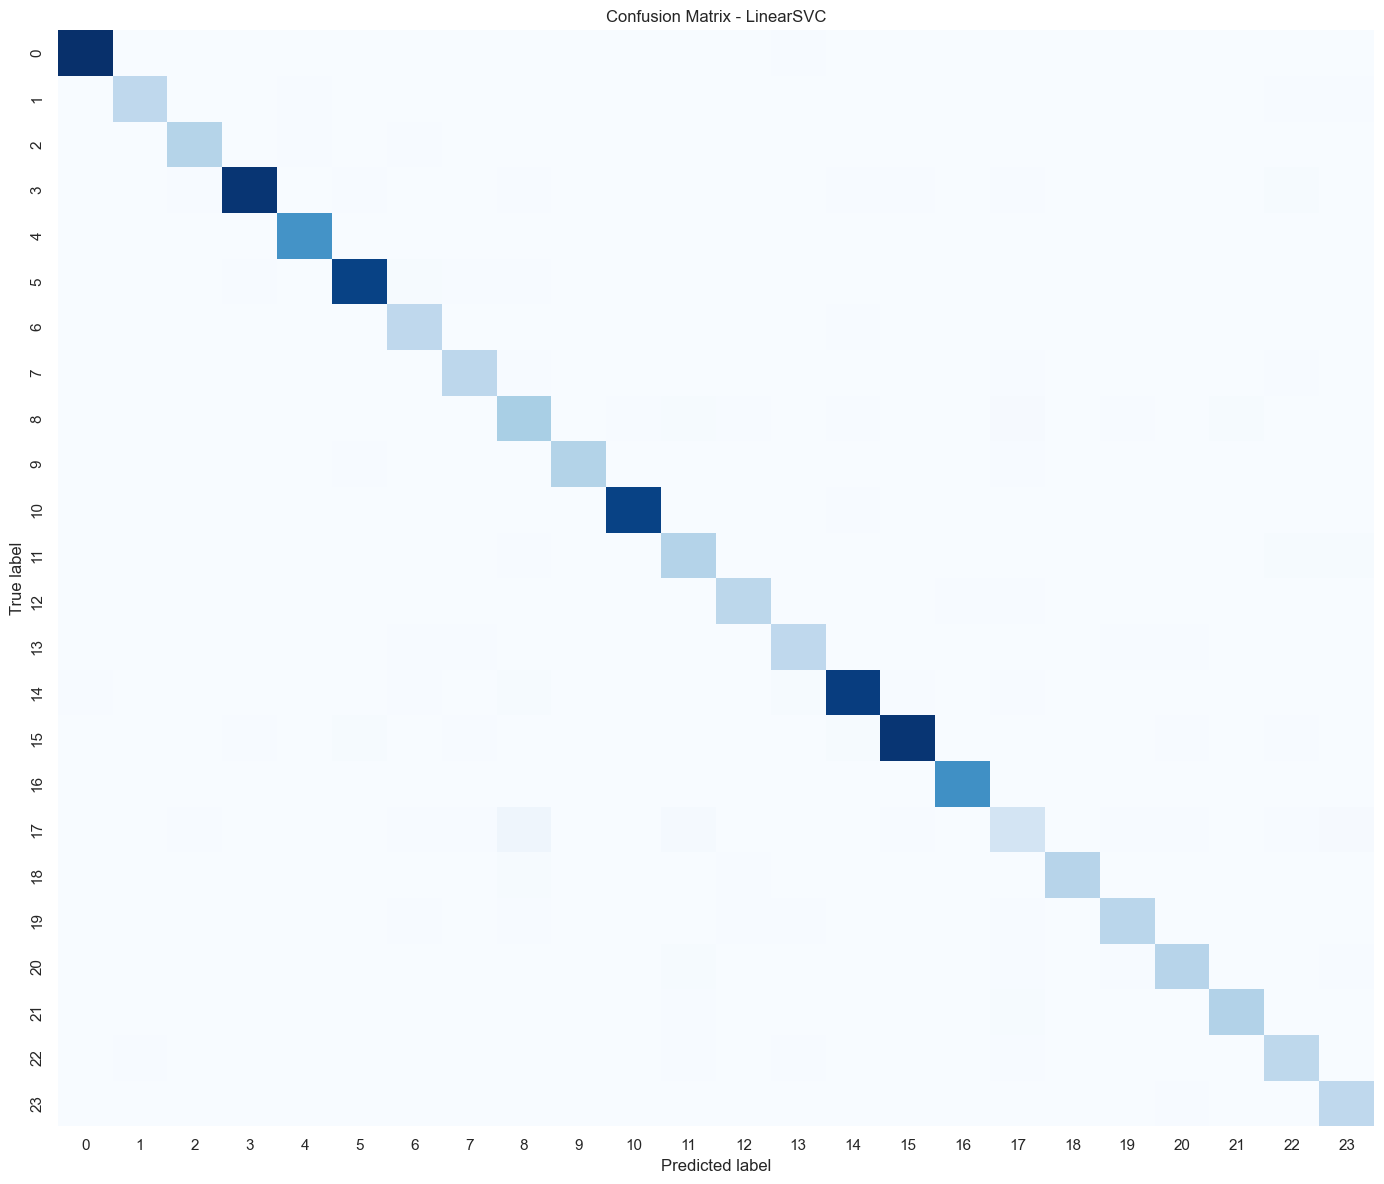

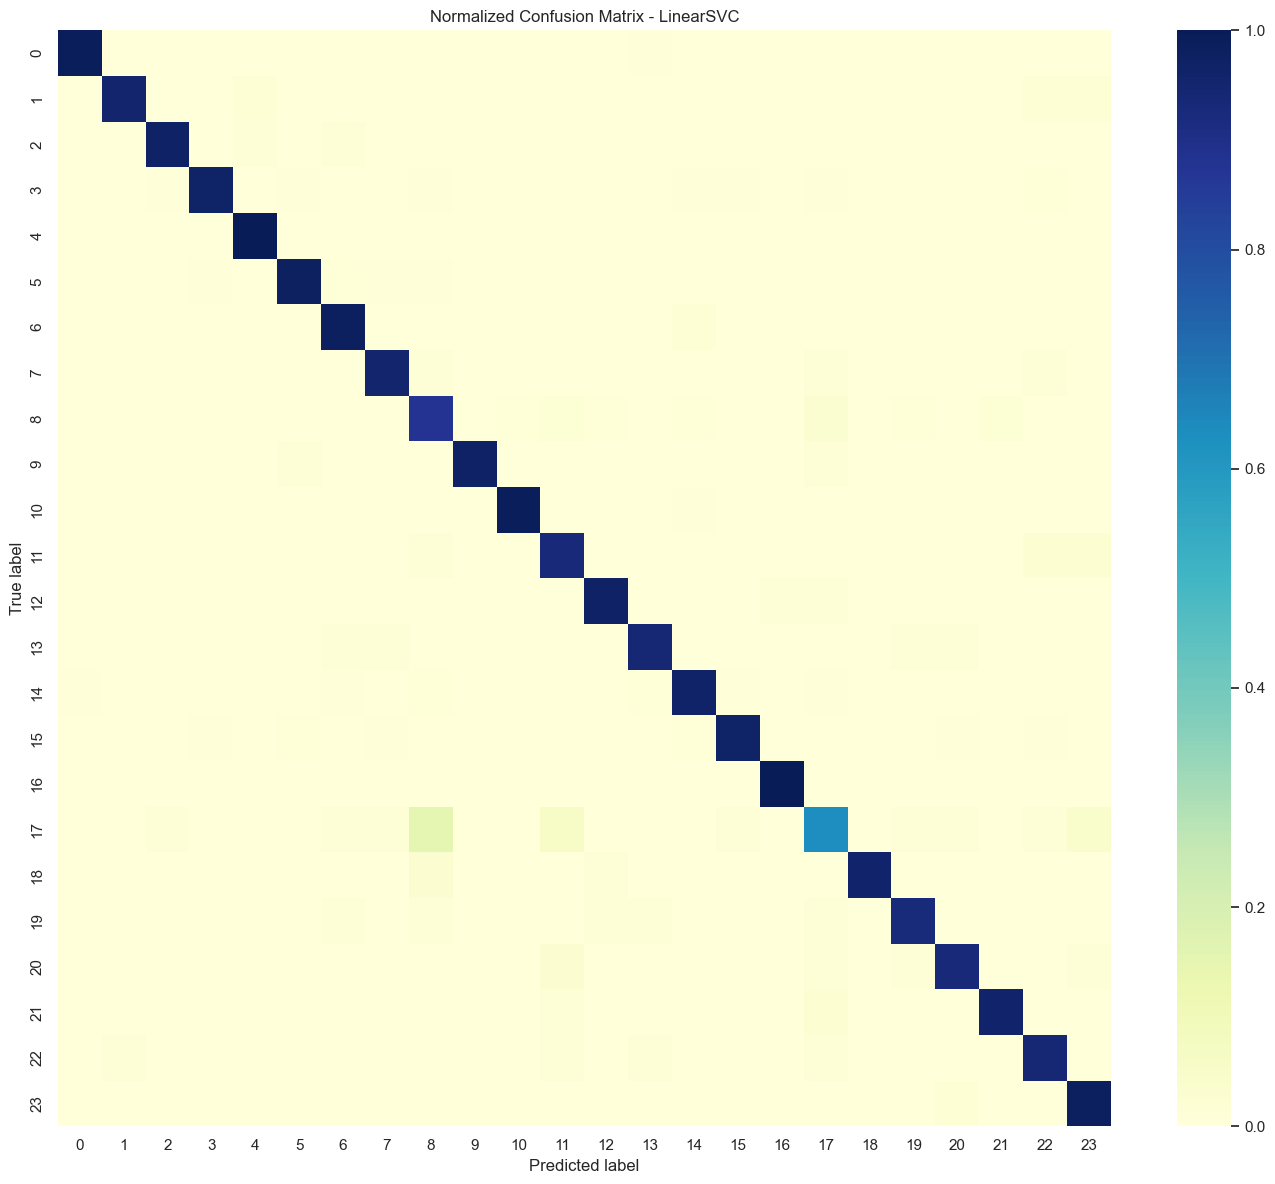

In [45]:
# Retrain the best classical model on train + validation data, then evaluate on the test set.
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
X_trainval = tfidf_vectorizer.fit_transform(trainval_df["clean_title"])
y_trainval = trainval_df["category_id"].to_numpy()
X_test_final = tfidf_vectorizer.transform(test_df["clean_title"])

general_model = models[best_model_name]
general_model.fit(X_trainval, y_trainval)

test_pred = general_model.predict(X_test_final)
test_accuracy = accuracy_score(y_test, test_pred)
test_f1_macro = f1_score(y_test, test_pred, average="macro")

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1:  {test_f1_macro:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, test_pred, target_names=label_encoder.classes_, zero_division=0))

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(y_test, test_pred, normalize="true")
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap="YlGnBu", cbar=True)
plt.title(f"Normalized Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

## 5) Validation-loss tracking and overfitting control

A compact neural model is trained with regularization and early stopping so we can explicitly visualize training loss versus validation loss.

Epoch 01 | train_loss=0.5856 | val_loss=0.5970 | train_acc=0.9082 | val_acc=0.8995
Epoch 02 | train_loss=0.2866 | val_loss=0.3298 | train_acc=0.9304 | val_acc=0.9175
Epoch 03 | train_loss=0.2281 | val_loss=0.2911 | train_acc=0.9421 | val_acc=0.9275
Epoch 04 | train_loss=0.1989 | val_loss=0.2781 | train_acc=0.9469 | val_acc=0.9293
Epoch 05 | train_loss=0.1792 | val_loss=0.2721 | train_acc=0.9499 | val_acc=0.9289
Epoch 06 | train_loss=0.1640 | val_loss=0.2694 | train_acc=0.9531 | val_acc=0.9297
Epoch 07 | train_loss=0.1517 | val_loss=0.2689 | train_acc=0.9562 | val_acc=0.9289
Epoch 08 | train_loss=0.1413 | val_loss=0.2697 | train_acc=0.9595 | val_acc=0.9278
Epoch 09 | train_loss=0.1323 | val_loss=0.2717 | train_acc=0.9620 | val_acc=0.9297
Epoch 10 | train_loss=0.1244 | val_loss=0.2743 | train_acc=0.9644 | val_acc=0.9289
Epoch 11 | train_loss=0.1173 | val_loss=0.2776 | train_acc=0.9658 | val_acc=0.9282
Epoch 12 | train_loss=0.1110 | val_loss=0.2815 | train_acc=0.9677 | val_acc=0.9278
Earl

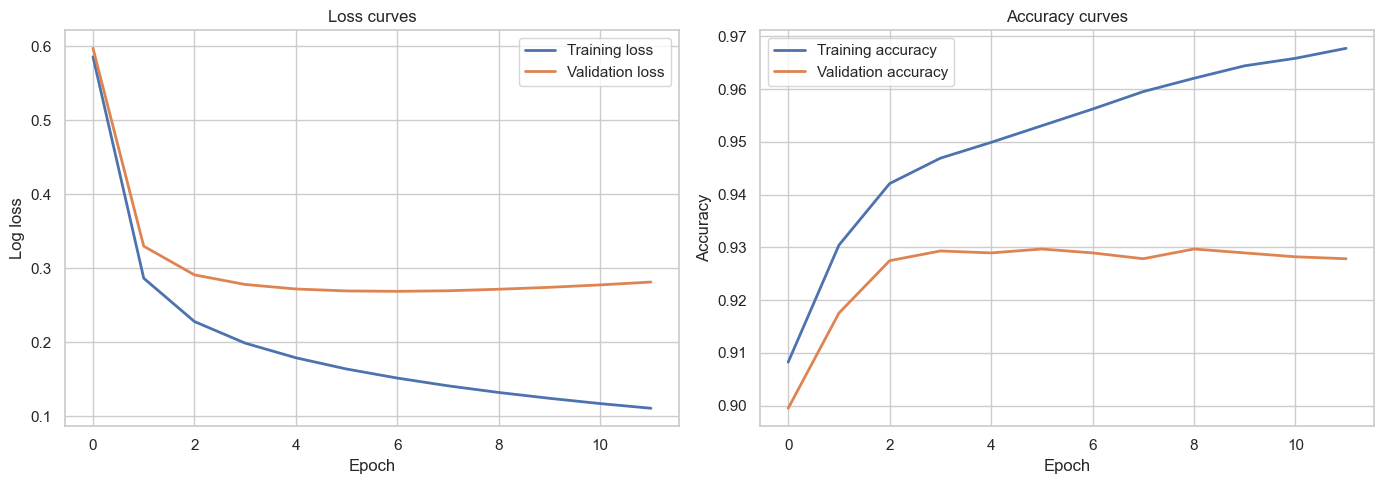

Neural model test accuracy: 0.9352
Neural model test macro F1: 0.9135


In [46]:
# Build a smaller dense feature space for a neural model and track train/validation loss.
svd_components = min(300, max(2, X_train.shape[1] - 1))
svd = TruncatedSVD(n_components=svd_components, random_state=RANDOM_STATE)

X_train_nn = svd.fit_transform(X_train)
X_val_nn = svd.transform(X_val)
X_test_nn = svd.transform(X_test)

nn_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    random_state=RANDOM_STATE,
    max_iter=1,
    warm_start=False,
    shuffle=True,
)

classes = np.unique(y_train)
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
}

best_val_loss = np.inf
best_nn_model = None
patience = 5
wait = 0
max_epochs = 40

for epoch in range(1, max_epochs + 1):
    if epoch == 1:
        nn_model.partial_fit(X_train_nn, y_train, classes=classes)
    else:
        nn_model.partial_fit(X_train_nn, y_train)

    train_prob = nn_model.predict_proba(X_train_nn)
    val_prob = nn_model.predict_proba(X_val_nn)
    train_pred = np.argmax(train_prob, axis=1)
    val_pred = np.argmax(val_prob, axis=1)

    train_loss = log_loss(y_train, train_prob, labels=classes)
    val_loss = log_loss(y_val, val_prob, labels=classes)
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_nn_model = copy.deepcopy(nn_model)
        wait = 0
    else:
        wait += 1

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

    if wait >= patience:
        print(f"Early stopping triggered after epoch {epoch}.")
        break

if best_nn_model is None:
    best_nn_model = nn_model

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Training loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation loss", linewidth=2)
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_accuracy"], label="Training accuracy", linewidth=2)
plt.plot(history["val_accuracy"], label="Validation accuracy", linewidth=2)
plt.title("Accuracy curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

nn_test_prob = best_nn_model.predict_proba(X_test_nn)
nn_test_pred = np.argmax(nn_test_prob, axis=1)
print("Neural model test accuracy:", round(accuracy_score(y_test, nn_test_pred), 4))
print("Neural model test macro F1:", round(f1_score(y_test, nn_test_pred, average='macro'), 4))

## 6) Extra visualizations and prediction helper

We finish with a few more diagnostics: class-wise F1 scores, top mistakes, and a reusable prediction function for new titles.

,label,precision,recall,f1-score,support
16,Medical,0.993007,1.000000,0.996491,142.0
0,Blockchain and Solidity Programming,0.995575,0.995575,0.995575,226.0
10,Flutter and Firebase App Development,0.995261,0.995261,0.995261,211.0
4,Commerce,0.985816,1.000000,0.992857,139.0
9,Ethical Hacking and Network Security Full Course,1.000000,0.972222,0.985915,72.0
5,Data Science and Data Analytics,0.981308,0.976744,0.979021,215.0
18,Pharmacology and Drug Interaction Studies,1.000000,0.957143,0.978102,70.0
3,Cloud Computing AWS Azure,0.990991,0.964912,0.977778,228.0
15,Machine Learning and Deep Learning Course,0.986547,0.964912,0.975610,228.0
2,Chartered Accountancy and Financial Auditing,0.971429,0.971429,0.971429,70.0


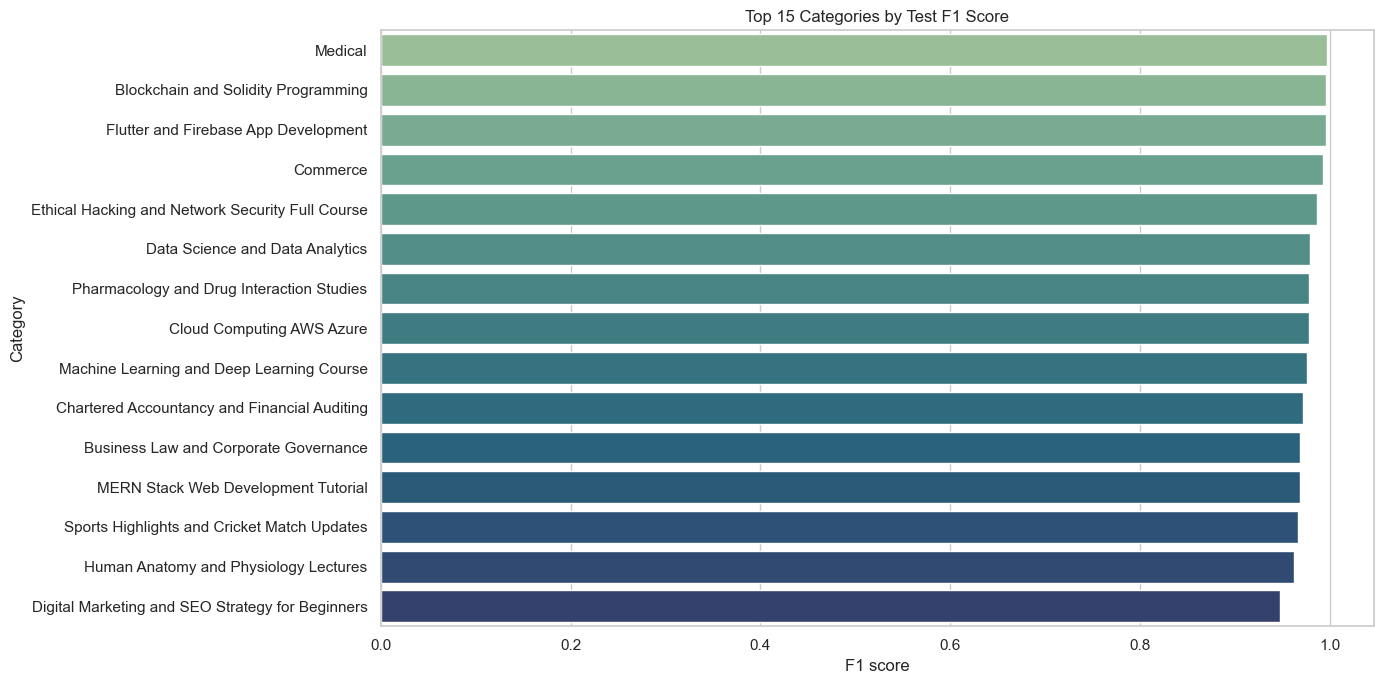

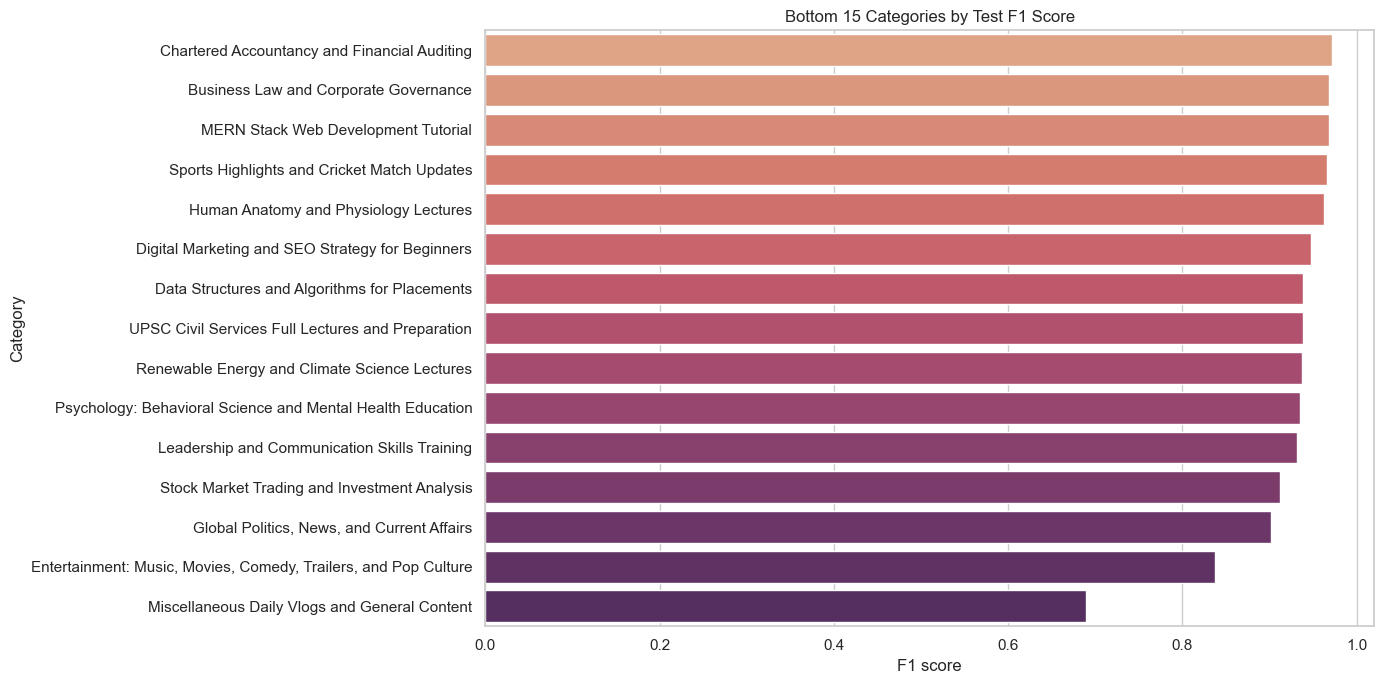

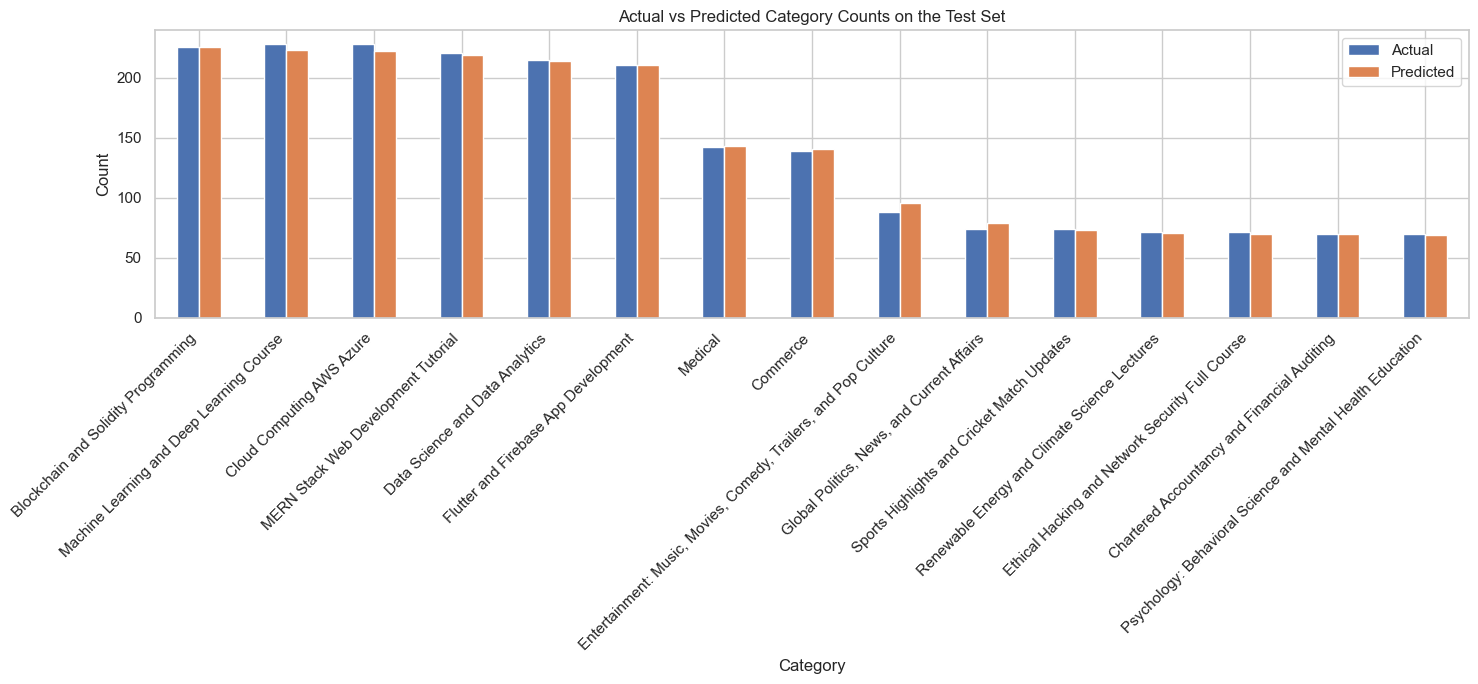

Example title: Complete PySpark Tutorial | Learn PySpark from Basics to Advanced Step-by-Step
Predicted category: Data Science and Data Analytics
Predicted category id: 5


In [47]:
# Class-wise F1 scores for the best classical model.
report_dict = classification_report(y_test, test_pred, target_names=label_encoder.classes_, zero_division=0, output_dict=True)
report_df = (
    pd.DataFrame(report_dict).T
    .reset_index()
    .rename(columns={"index": "label"})
)
report_df = report_df[report_df["label"].isin(label_encoder.classes_)].sort_values("f1-score", ascending=False)

display(report_df.head(15)[["label", "precision", "recall", "f1-score", "support"]])

plt.figure(figsize=(14, 7))
sns.barplot(data=report_df.head(15), x="f1-score", y="label", palette="crest")
plt.title("Top 15 Categories by Test F1 Score")
plt.xlabel("F1 score")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Show the categories that are hardest for the model.
plt.figure(figsize=(14, 7))
sns.barplot(data=report_df.tail(15), x="f1-score", y="label", palette="flare")
plt.title("Bottom 15 Categories by Test F1 Score")
plt.xlabel("F1 score")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Compare actual vs predicted category counts for the test set.
actual_counts = pd.Series(y_test).map(dict(zip(category_map["category_id"], category_map["Category"]))).value_counts()
pred_counts = pd.Series(test_pred).map(dict(zip(category_map["category_id"], category_map["Category"]))).value_counts()
comparison = pd.DataFrame({"Actual": actual_counts, "Predicted": pred_counts}).fillna(0)
comparison = comparison.loc[comparison.sum(axis=1).sort_values(ascending=False).head(15).index]

comparison.plot(kind="bar", figsize=(15, 7))
plt.title("Actual vs Predicted Category Counts on the Test Set")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Reusable prediction helper for new titles.
def predict_category(title: str):
    cleaned = clean_text(title)
    features = tfidf_vectorizer.transform([cleaned])
    predicted_id = general_model.predict(features)[0]
    predicted_name = label_encoder.inverse_transform([predicted_id])[0]
    return predicted_name, int(predicted_id)

example_title = "Complete PySpark Tutorial | Learn PySpark from Basics to Advanced Step-by-Step"
predicted_category, predicted_id = predict_category(example_title)
print("Example title:", example_title)
print("Predicted category:", predicted_category)
print("Predicted category id:", predicted_id)

In [49]:
# Quick manual prediction: replace the text below with any title you want.
new_title = "WEIRDEST Sequence in NBA History 😭🤨 #shorts - YouTube"

if isinstance(new_title, str) and new_title.strip():
    predicted_category, predicted_id = predict_category(new_title)
    print(f"Title: {new_title}")
    print(f"Predicted category: {predicted_category}")
    print(f"Predicted category id: {predicted_id}")
else:
    print("Please enter a non-empty title string.")

# Optional: predict several titles at once by editing the list below.
# sample_titles = [
#     "Complete PySpark Tutorial | Learn PySpark from Basics to Advanced Step-by-Step",
#     "Flutter Push Notification Tutorial | Part 6 | Testing Notifications with Firebase and Postman",
# ]
#
# for title in sample_titles:
#     category, cid = predict_category(title)
#     print(f"{title} -> {category} (id={cid})")

Title: WEIRDEST Sequence in NBA History 😭🤨 #shorts - YouTube
Predicted category: Miscellaneous Daily Vlogs and General Content
Predicted category id: 17


In [50]:
# Export the trained model and preprocessing objects to pickle files for Flask deployment
import pickle
import os

export_dir = "model_exports"
os.makedirs(export_dir, exist_ok=True)

# Export the main model
with open(os.path.join(export_dir, "final_model.pkl"), "wb") as f:
    pickle.dump(general_model, f)

# Export the TF-IDF vectorizer
with open(os.path.join(export_dir, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

# Export the label encoder
with open(os.path.join(export_dir, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

# Export the neural model and SVD for advanced predictions
with open(os.path.join(export_dir, "neural_model.pkl"), "wb") as f:
    pickle.dump(best_nn_model, f)

with open(os.path.join(export_dir, "svd_transformer.pkl"), "wb") as f:
    pickle.dump(svd, f)

print(f"✓ Model exported to: {export_dir}")
print(f"  - final_model.pkl (LinearSVC classifier)")
print(f"  - tfidf_vectorizer.pkl (TF-IDF transformer)")
print(f"  - label_encoder.pkl (Category encoder)")
print(f"  - neural_model.pkl (Neural network model)")
print(f"  - svd_transformer.pkl (Dimensionality reduction)")

✓ Model exported to: model_exports
  - final_model.pkl (LinearSVC classifier)
  - tfidf_vectorizer.pkl (TF-IDF transformer)
  - label_encoder.pkl (Category encoder)
  - neural_model.pkl (Neural network model)
  - svd_transformer.pkl (Dimensionality reduction)
